# Notebook 01: Data Exploration & Descriptive Statistics

**Replication of:** Appel, Pan & Roberts (2023), "Partisan Conflict over Content Moderation Is More Than Disagreement about Facts", *Science Advances*.

This notebook loads the main experiment dataset, explores its structure, computes descriptive statistics by party, and produces descriptive bar charts showing partisan differences in content moderation preferences.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    load_main_data, OUTCOME_LABELS, CONTROLS,
    compute_weighted_means, plot_descriptive_bars
)

pd.set_option('display.max_columns', 35)
pd.set_option('display.width', 120)
%matplotlib inline

## 1. Load Data & Inspect Structure

In [2]:
df = load_main_data()
print(f'Dataset shape: {df.shape[0]} observations x {df.shape[1]} variables')
print(f'Unique respondents: {df["id"].nunique()}')
print(f'Headlines per respondent: {df.groupby("id").size().value_counts().to_dict()}')
df.head()

Dataset shape: 2240 observations x 28 variables
Unique respondents: 1120
Headlines per respondent: {2: 1120}


,id,accuracy_order,social_media_post_removed,social_media_post_flagged,age,gender,education,household_income,race,weight,hispanic,party_id,party_id_dem,party_id_rep,headline_order,remove,censorship,accuracy,harm,headline,headline_orientation,headline_pro_dem,headline_pro_rep,accuracy_binary,social_media_most_common_newsformat,political_interest,aligned,race_white
0,1,1,0.0,0.0,77,0,2,2,White,1.0419,0,Democrat,1,0,0,1.0,0.0,1.0,1.0,headline_pro_rep_3,pro_rep,0,1,0.0,0.0,3.00,0,1
1,1,1,0.0,0.0,77,0,2,2,White,1.0419,0,Democrat,1,0,1,1.0,0.0,2.0,1.0,headline_pro_dem_7,pro_dem,1,0,0.0,0.0,3.00,1,1
2,2,0,0.0,0.0,75,1,2,4,Non-White,0.4956,0,Democrat,1,0,0,0.0,1.0,3.0,0.0,headline_pro_rep_6,pro_rep,0,1,1.0,0.0,2.25,0,0
3,2,0,0.0,0.0,75,1,2,4,Non-White,0.4956,0,Democrat,1,0,1,0.0,0.0,1.0,0.0,headline_pro_dem_1,pro_dem,1,0,0.0,0.0,2.25,1,0
4,3,0,NaN,NaN,59,1,2,5,Non-White,0.6975,0,Republican,0,1,0,0.0,1.0,2.0,0.0,headline_pro_dem_4,pro_dem,1,0,0.0,0.0,2.00,0,0


In [3]:
# Variable types and missing values
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(1),
    'n_unique': df.nunique(),
})
info_df

,dtype,non_null,missing,pct_missing,n_unique
id,int64,2240,0,0.0,1120
accuracy_order,int64,2240,0,0.0,2
social_media_post_removed,float64,1792,448,20.0,2
social_media_post_flagged,float64,1776,464,20.7,2
age,int64,2240,0,0.0,72
gender,int64,2240,0,0.0,2
education,int64,2240,0,0.0,5
household_income,int64,2240,0,0.0,7
race,object,2240,0,0.0,2
weight,float64,2240,0,0.0,756


## 2. Codebook

In [4]:
codebook_path = os.path.join('..', 'dataverse_files', 'data', 'intermediate', 'survey', 'codebook.csv')
if os.path.exists(codebook_path):
    codebook = pd.read_csv(codebook_path)
    display(codebook)
else:
    print('Codebook not found at:', codebook_path)

,Variable,Value,Label Type,Label
0,accuracy,NaN,variable label,"To the best of your knowledge, how accurate is..."
1,accuracy,1,value label,Not at all accurate
2,accuracy,2,value label,Not very accurate
3,accuracy,3,value label,Somewhat accurate
4,accuracy,4,value label,Very accurate
...,...,...,...,...
92,social_media_post_flagged,1,value label,"Yes, I have experienced or done this"
93,social_media_post_removed,NaN,variable label,Have you ever experienced the following? - Had...
94,social_media_post_removed,0,value label,"No, I have not experienced or done this"
95,social_media_post_removed,1,value label,"Yes, I have experienced or done this"


## 3. Descriptive Statistics by Party (Table S3)

In [17]:
# Demographics by party (respondent-level — deduplicate to one row per id)
respondent_vars = ['age', 'gender', 'education', 'household_income', 'hispanic',
                   'political_interest', 'social_media_most_common_newsformat',
                   'social_media_post_flagged', 'social_media_post_removed']

df_resp = df.drop_duplicates(subset='id')

desc_by_party = df_resp.groupby('party_id', observed=False)[respondent_vars].agg(['mean', 'std', 'count']).round(3)
desc_by_party

age               gender              education              household_income              hispanic  \
              mean     std count   mean    std count      mean    std count             mean    std count     mean   
party_id                                                                                                             
Democrat    51.880  16.834   673  0.597  0.491   673     3.269  1.155   673            4.651  1.738   673    0.138   
Republican  55.407  15.857   447  0.512  0.500   447     3.105  1.082   447            4.998  1.646   447    0.123   

                        political_interest              social_media_most_common_newsformat               \
              std count               mean    std count                                mean    std count   
party_id                                                                                                   
Democrat    0.345   673              2.867  0.651   660                               0.168  0.374   662   
Republican  0.329   447              2.755  0.705   441                               0.148  0.355   440   

           social_media_post_flagged              social_media_post_removed               
                                mean    std count                      mean    std count  
party_id                                                                                  
Democrat                       0.114  0.318   527                     0.094  0.292   534  
Republican                     0.199  0.400   361                     0.191  0.393   362

In [18]:
# Race breakdown by party
print('Race distribution by party:')
pd.crosstab(df_resp['party_id'], df_resp['race'], normalize='index').round(3) * 100

Race distribution by party:


race,Non-White,White
party_id,,
Democrat,60.3,39.7
Republican,19.0,81.0


In [7]:
# Outcome variables by party (observation-level, weighted)
outcomes = ['remove', 'harm', 'censorship', 'accuracy', 'accuracy_binary']

weighted_means = []
for party in ['Democrat', 'Republican']:
    mask = df['party_id'] == party
    sub = df.loc[mask]
    for var in outcomes:
        vals = sub.dropna(subset=[var, 'weight'])
        wmean = np.average(vals[var], weights=vals['weight'])
        weighted_means.append({'party_id': party, 'variable': var, 'weighted_mean': wmean})

wm_df = pd.DataFrame(weighted_means).pivot(index='variable', columns='party_id', values='weighted_mean').round(4)
wm_df['gap'] = (wm_df['Democrat'] - wm_df['Republican']).round(4)
wm_df

party_id,Democrat,Republican,gap
variable,,,
accuracy,1.6760,1.9332,-0.2572
accuracy_binary,0.1790,0.2651,-0.0861
censorship,0.2872,0.6455,-0.3583
harm,0.4935,0.2709,0.2226
remove,0.6903,0.3410,0.3493


In [8]:
# Share rating headlines as accurate
pct_accurate = 100 * df['accuracy_binary'].mean()
print(f'Share rating headlines as somewhat/very accurate: {pct_accurate:.2f}%')

Share rating headlines as somewhat/very accurate: 20.32%


## 4. Weighted Means by Party × Alignment

In [9]:
means_remove = compute_weighted_means(df, 'remove')
means_harm = compute_weighted_means(df, 'harm')
means_cens = compute_weighted_means(df, 'censorship')

print('=== Intent to Remove ===')
display(means_remove.round(4))
print('\n=== Intent to Report Harm ===')
display(means_harm.round(4))
print('\n=== Perception of Censorship ===')
display(means_cens.round(4))

=== Intent to Remove ===


,party_id,aligned,mean,se,conf_low,conf_high
0,Democrat,Misaligned,0.7455,0.0205,0.7053,0.7857
1,Democrat,Aligned,0.6355,0.0227,0.5911,0.6800
2,Democrat,Overall,0.6903,0.0154,0.6601,0.7206
3,Republican,Misaligned,0.3400,0.0256,0.2898,0.3902
4,Republican,Aligned,0.3420,0.0255,0.2920,0.3920
5,Republican,Overall,0.3410,0.0181,0.3056,0.3764



=== Intent to Report Harm ===


,party_id,aligned,mean,se,conf_low,conf_high
0,Democrat,Misaligned,0.5586,0.0232,0.5130,0.6041
1,Democrat,Aligned,0.4284,0.0230,0.3833,0.4736
2,Democrat,Overall,0.4935,0.0166,0.4610,0.5260
3,Republican,Misaligned,0.2545,0.0230,0.2095,0.2996
4,Republican,Aligned,0.2874,0.0246,0.2392,0.3355
5,Republican,Overall,0.2709,0.0168,0.2379,0.3040



=== Perception of Censorship ===


,party_id,aligned,mean,se,conf_low,conf_high
0,Democrat,Misaligned,0.2809,0.0242,0.2335,0.3283
1,Democrat,Aligned,0.2934,0.0244,0.2455,0.3413
2,Democrat,Overall,0.2872,0.0172,0.2535,0.3209
3,Republican,Misaligned,0.6462,0.0282,0.5909,0.7016
4,Republican,Aligned,0.6448,0.0284,0.5892,0.7004
5,Republican,Overall,0.6455,0.0200,0.6063,0.6847


## 5. Descriptive Bar Charts

These replicate the descriptive panels in Figures 1 and 3 of the paper, showing partisan differences in content moderation preferences broken down by headline alignment.

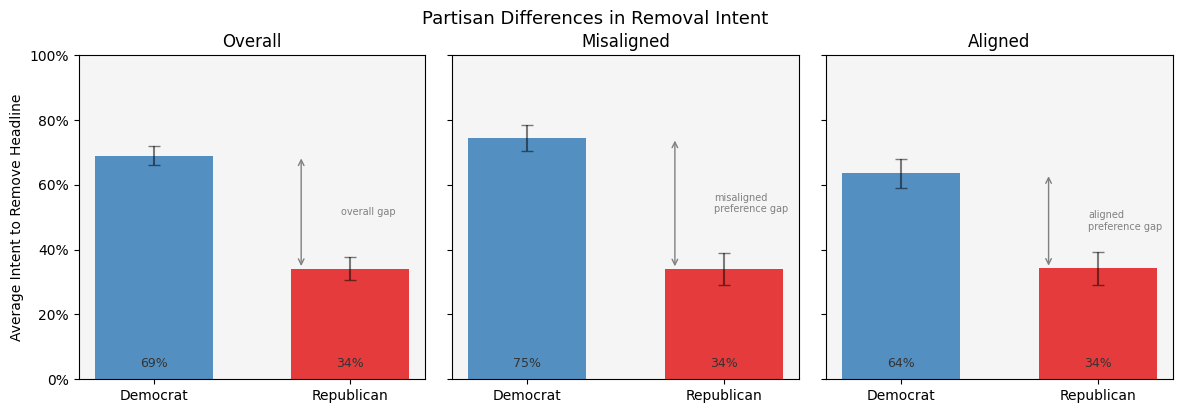

In [10]:
fig_remove, _ = plot_descriptive_bars(means_remove, 'Average Intent to Remove Headline')
fig_remove.suptitle('Partisan Differences in Removal Intent', fontsize=13, y=1.02)
plt.show()

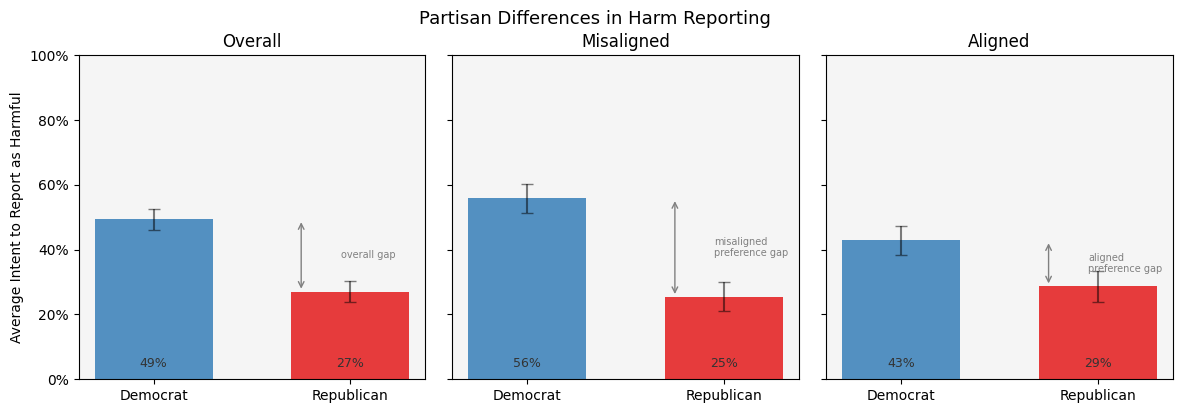

In [11]:
fig_harm, _ = plot_descriptive_bars(means_harm, 'Average Intent to Report as Harmful')
fig_harm.suptitle('Partisan Differences in Harm Reporting', fontsize=13, y=1.02)
plt.show()

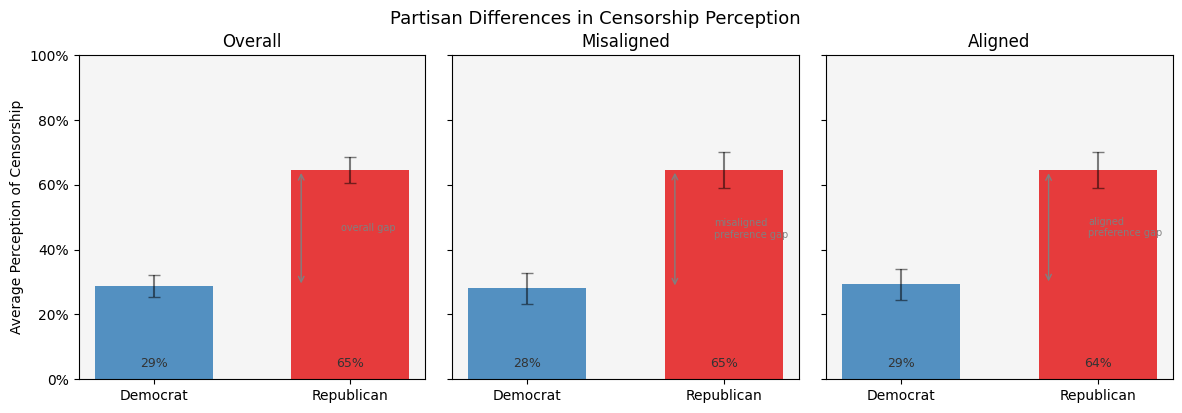

In [12]:
fig_cens, _ = plot_descriptive_bars(means_cens, 'Average Perception of Censorship')
fig_cens.suptitle('Partisan Differences in Censorship Perception', fontsize=13, y=1.02)
plt.show()

## 6. Inaccurate Headlines Subgroup

Repeat for the subset of headlines rated as inaccurate (accuracy_binary == 0), which is the key subgroup in Figures 1-2.

Inaccurate subgroup: 1729 observations (77.2%)


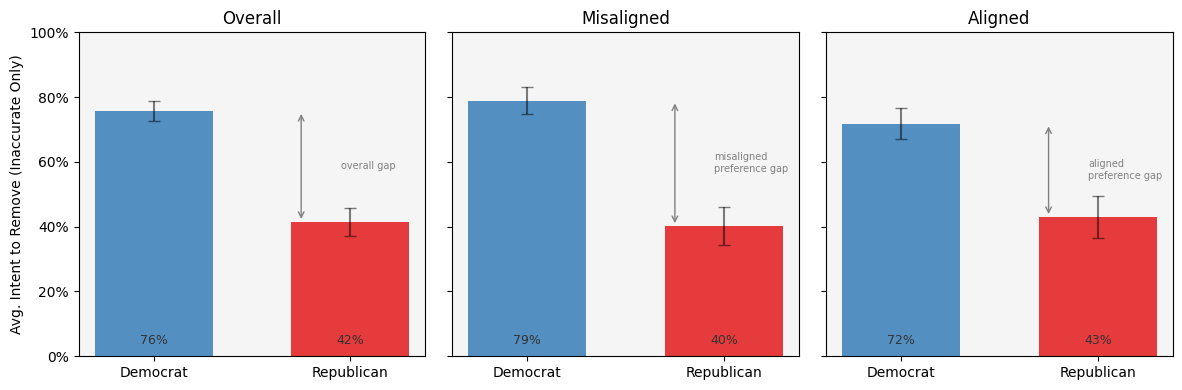

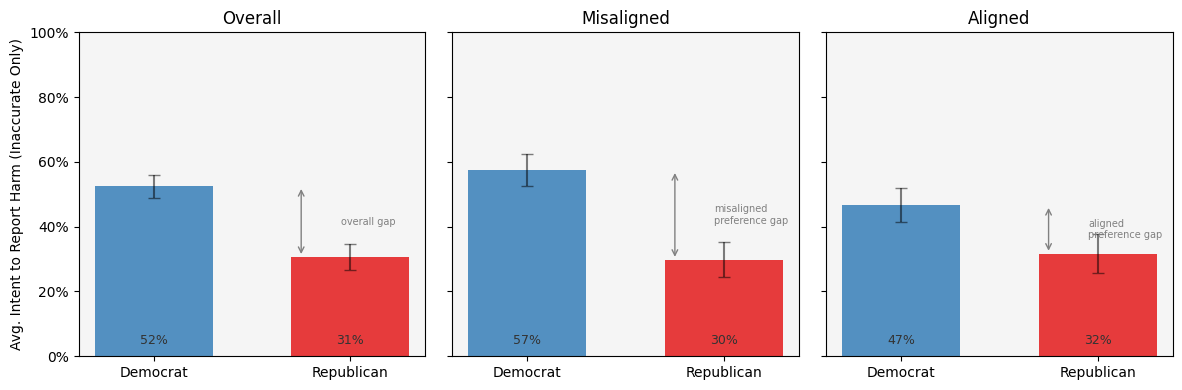

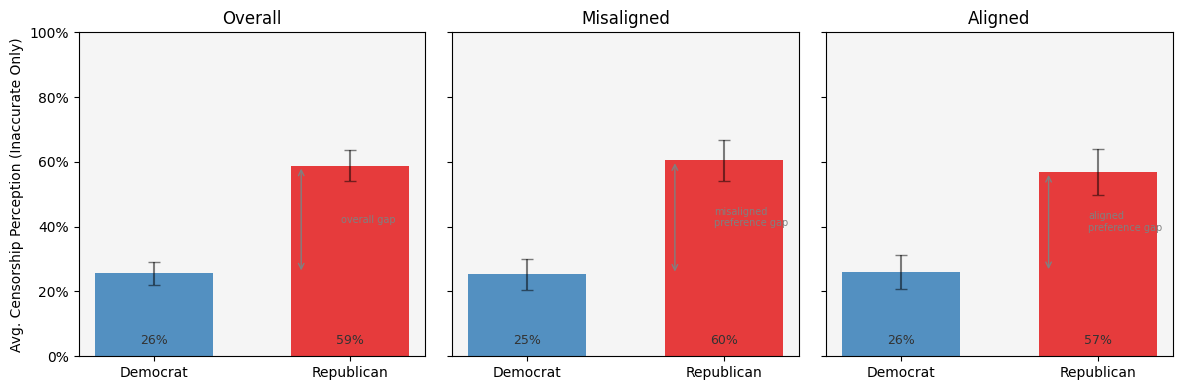

In [13]:
df_inacc = df[df['accuracy_binary'] == 0].copy()
print(f'Inaccurate subgroup: {len(df_inacc)} observations ({len(df_inacc)/len(df)*100:.1f}%)')

means_remove_inacc = compute_weighted_means(df_inacc, 'remove')
means_harm_inacc = compute_weighted_means(df_inacc, 'harm')
means_cens_inacc = compute_weighted_means(df_inacc, 'censorship')

fig_ri, _ = plot_descriptive_bars(means_remove_inacc, 'Avg. Intent to Remove (Inaccurate Only)')
plt.show()

fig_hi, _ = plot_descriptive_bars(means_harm_inacc, 'Avg. Intent to Report Harm (Inaccurate Only)')
plt.show()

fig_ci, _ = plot_descriptive_bars(means_cens_inacc, 'Avg. Censorship Perception (Inaccurate Only)')
plt.show()

## 7. Headline-Level Breakdown

In [23]:
# Accuracy by headline and party
headline_acc = df.groupby(['headline', 'party_id'], observed=False).apply( 
    lambda g: pd.Series({
        'mean_accuracy': np.average(g['accuracy'].dropna(), weights=g.loc[g['accuracy'].notna(), 'weight']) if g['accuracy'].notna().any() else np.nan,
        'pct_inaccurate': (g['accuracy_binary'] == 0).mean() * 100,
        'mean_remove': np.average(g['remove'].dropna(), weights=g.loc[g['remove'].notna(), 'weight']) if g['remove'].notna().any() else np.nan,
        'n': len(g),
    }),include_groups=False
).round(3)

headline_acc.reset_index(inplace=True)

# Show accuracy ratings by headline — pivoted
pivot_acc = headline_acc.pivot(index='headline', columns='party_id', values='mean_accuracy')
pivot_acc['abs_diff'] = (pivot_acc['Democrat'] - pivot_acc['Republican']).abs().round(3)
pivot_acc = pivot_acc.sort_values('abs_diff')
print('Headlines sorted by partisan consensus on accuracy (smallest diff = most consensus):')
display(pivot_acc)

Headlines sorted by partisan consensus on accuracy (smallest diff = most consensus):


party_id,Democrat,Republican,abs_diff
headline,,,
headline_pro_dem_4,1.550,1.538,0.012
headline_pro_rep_7,1.699,1.660,0.039
headline_pro_dem_1,1.730,1.662,0.068
headline_pro_dem_3,2.053,2.121,0.068
headline_pro_dem_9,2.045,2.154,0.109
headline_pro_dem_8,1.925,2.135,0.210
headline_pro_dem_7,1.618,1.357,0.261
headline_pro_rep_9,1.226,1.601,0.375
headline_pro_dem_5,1.873,1.462,0.411


## Summary

Key findings from descriptive analysis:
- **Removal**: Democrats (~69%) are substantially more likely than Republicans (~34%) to favor removing headlines
- **Harm**: Democrats (~49%) report headlines as more harmful than Republicans (~27%)
- **Censorship**: Republicans (~65%) are more likely than Democrats (~29%) to view removal as censorship
- These gaps persist even when both parties agree a headline is inaccurate
- Party promotion effect: partisans are more willing to remove opposing-party headlines than co-party headlines